In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tldextract


In [2]:
df = pd.read_csv('../data/cleaned_malicious_phish.csv')

In [3]:
print(df.head())
print(df.tail())
print(df.info)




                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement
                                                  url      type
641120        xbox360.ign.com/objects/850/850402.html  phishing
641121   games.teamxbox.com/xbox-360/1860/Dead-Space/  phishing
641122     www.gamespot.com/xbox360/action/deadspace/  phishing
641123  en.wikipedia.org/wiki/Dead_Space_(video_game)  phishing
641124      www.angelfire.com/goth/devilmaycrytonite/  phishing
<bound method DataFrame.info of                                                       url        type
0                                        br-icloud.com.br    phishing
1                     mp3raid.com/music/krizz_kaliko.h

In [4]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)

0


In [5]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [url, type]
Index: []


In [6]:
df_cleaned = df.drop_duplicates()

In [7]:
print(df_cleaned)

                                                      url        type
0                                        br-icloud.com.br    phishing
1                     mp3raid.com/music/krizz_kaliko.html      benign
2                         bopsecrets.org/rexroth/cr/1.htm      benign
3       http://www.garage-pirenne.be/index.php?option=...  defacement
4       http://adventure-nicaragua.net/index.php?optio...  defacement
...                                                   ...         ...
641120            xbox360.ign.com/objects/850/850402.html    phishing
641121       games.teamxbox.com/xbox-360/1860/Dead-Space/    phishing
641122         www.gamespot.com/xbox360/action/deadspace/    phishing
641123      en.wikipedia.org/wiki/Dead_Space_(video_game)    phishing
641124          www.angelfire.com/goth/devilmaycrytonite/    phishing

[641125 rows x 2 columns]


In [8]:
df.isna().values.any()


np.False_

In [9]:
df_cleaned.to_csv('cleaned_malicious_phish.csv', index=False)

In [10]:
def run_data_quality_audit(df):
    """
    Performs a comprehensive health check on a pandas DataFrame.
    Prints structural, formatting, and statistical data quality reports.
    """
    print("=" * 60)
    print("                 DATA QUALITY AUDIT REPORT              ")
    print("=" * 60)
    
    # 1. SHAPE & STRUCTURE
    print(f"\n[1] Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # 2. DUPLICATES
    duplicates = df.duplicated().sum()
    print(f"[2] Duplicate Rows: {duplicates} ({df.duplicated().mean()*100:.2f}%)")
    
    # 3. MISSING VALUES
    print("\n[3] Missing Values Per Column:")
    missing_data = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Percentage': (df.isnull().sum() / len(df)) * 100
    })
    missing_cols = missing_data[missing_data['Missing Count'] > 0]
    if not missing_cols.empty:
        print(missing_cols.to_string())
    else:
        print("    ✅ Perfect! No missing values found.")
        
    # 4. DATA TYPES & UNEXPECTED STRINGS
    print("\n[4] Column Data Types & Numeric Status:")
    for col in df.columns:
        dtype = df[col].dtype
        # Catch object columns that might contain mixed types
        mixed_types = df[col].apply(type).nunique() > 1
        mixed_msg = "⚠️ MIXED TYPES DETECTED" if mixed_types else "Clean"
        print(f"    - Column '{col}': {dtype} ({mixed_msg})")

    # 5. CATEGORICAL & TEXT CONSISTENCY (Object Columns)
    text_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(text_cols) > 0:
        print("\n[5] Text & Categorical Column Consistency:")
        for col in text_cols:
            unique_count = df[col].nunique()
            # Check for hidden whitespace issues
            has_whitespace = df[col].astype(str).str.map(lambda x: x != x.strip()).any()
            whitespace_msg = "⚠️ HAS LEADING/TRAILING WHITESPACE" if has_whitespace else "Clean"
            
            print(f"    - '{col}': {unique_count} unique values | {whitespace_msg}")
            if unique_count < 10:
                print(f"      Values: {df[col].unique()}")
    else:
        print("\n[5] Text & Categorical Columns: None found.")

    # 6. NUMERICAL BOUNDARY CHECKS
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        print("\n[6] Numerical Distribution Summary:")
        # Display Transposed summary statistics for easier reading
        print(df[num_cols].describe().T[['min', 'mean', 'max']])
    else:
        print("\n[6] Numerical Columns: None found.")
        
    print("\n" + "=" * 60)




In [11]:
print("Shape:", df.shape)

Shape: (641125, 2)


In [12]:
print("Total missing:", df.isnull().sum().sum())

Total missing: 0


In [13]:
print("Total duplicates:", df.duplicated().sum())

Total duplicates: 0


In [14]:
print("Whitespace issues:", any(df[c].astype(str).str.strip().str.len().ne(df[c].astype(str).str.len()).any() for c in df.select_dtypes(include='object')))


Whitespace issues: True


/var/folders/q9/1cvgqw212sn3z0wpcdxcn4t00000gn/T/ipykernel_21411/2157864170.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Whitespace issues:", any(df[c].astype(str).str.strip().str.len().ne(df[c].astype(str).str.len()).any() for c in df.select_dtypes(include='object')))


In [15]:
# 1. Clean all text/object columns by stripping whitespace
text_cols = df.select_dtypes(include=['object', 'category']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 2. Re-run the validation check to verify the fix
whitespace_check = any(
    df[c].astype(str).str.strip().str.len().ne(df[c].astype(str).str.len()).any() 
    for c in text_cols
)

print(f"Remaining whitespace issues: {whitespace_check}")


/var/folders/q9/1cvgqw212sn3z0wpcdxcn4t00000gn/T/ipykernel_21411/1662529570.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object', 'category']).columns


Remaining whitespace issues: False


In [16]:
import os

# 1. Define your folder and file name
folder_name = 'data'
file_name = 'cleaned_dataset.csv'
file_path = os.path.join(folder_name, file_name)

# 2. Create the folder automatically if it doesn't exist yet
os.makedirs(folder_name, exist_ok=True)

# 3. Save the clean data (index=False prevents adding an unneeded ID column)
df.to_csv(file_path, index=False)

print(f"✅ Cleaned dataset successfully saved to: {file_path}")


✅ Cleaned dataset successfully saved to: data/cleaned_dataset.csv


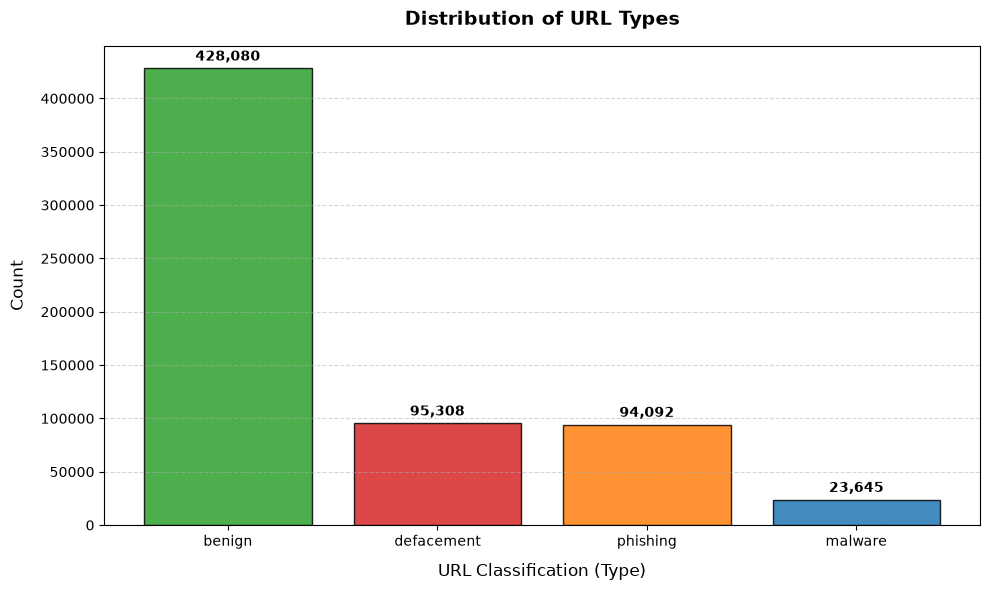

In [ ]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(10, 6))

colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd'][:len(type_counts)]
bars = plt.bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', alpha=0.85)

# Add numerical labels on top of each bar  (this is ALL the loop should do)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + (max(type_counts.values) * 0.01),
             f'{height:,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Everything below runs ONCE, after the loop — note it's dedented to the left margin
plt.title('Distribution of URL Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('URL Classification (Type)', fontsize=12, labelpad=10)
plt.ylabel('Count', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../images/url_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

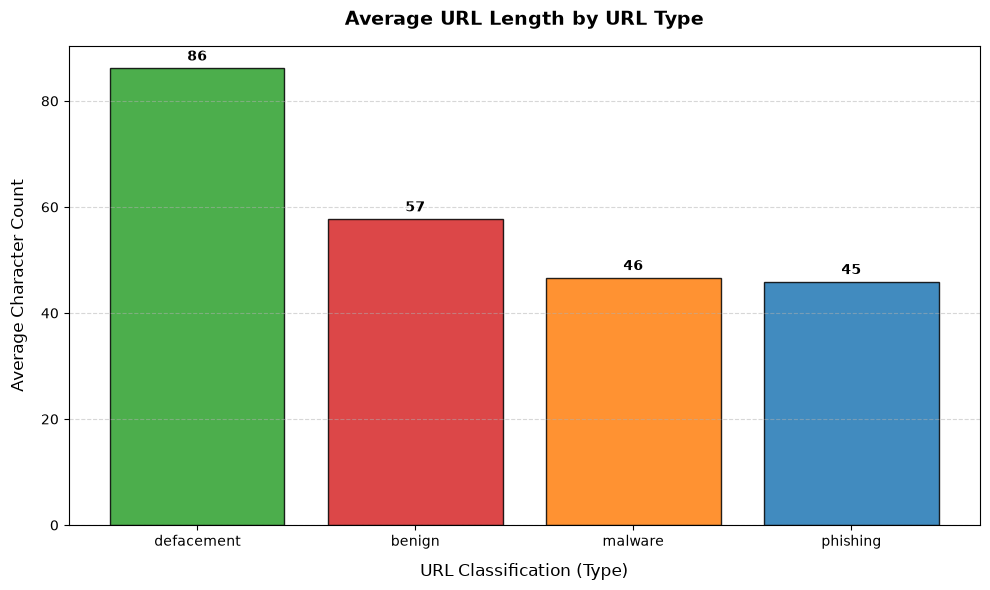

In [ ]:
# 1. Feature Engineering: Create a numerical feature from the URL string
df['url_length'] = df['url'].str.len()

# 2. Aggregate data: Calculate the average URL length for each type
avg_length = df.groupby('type')['url_length'].mean().sort_values(ascending=False)

# 3. Initialize chart
plt.figure(figsize=(10, 6))

# 4. Plot bars using your original styling logic
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd'][:len(avg_length)]
bars = plt.bar(avg_length.index, avg_length.values, color=colors, edgecolor='black', alpha=0.85)
    
# 5. Add numerical labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height + (max(avg_length.values) * 0.01),
        f'{int(height):,}', # Displays as a whole number with comma formatting
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# 6. Styling and titles
plt.title('Average URL Length by URL Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('URL Classification (Type)', fontsize=12, labelpad=10)
plt.ylabel('Average Character Count', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
    
# 7. Render and save chart
plt.tight_layout()
plt.savefig('../images/url_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
label_map = {"benign": 0, "phishing": 1, "malware": 1, "defacement": 1}
df["label"] = df["type"].map(label_map)
df["label"].isna().sum()   # must be 0 — any NaN = a label the map missed

np.int64(0)

In [20]:
df.duplicated().sum()                 # fully identical (url, type) rows
df.duplicated(subset="url").sum()     # same URL, regardless of label

np.int64(6)

In [21]:
type_counts = df.groupby("url")["type"].nunique()
conflicts = type_counts[type_counts > 1]
len(conflicts)

6

In [22]:
df[df["url"].isin(conflicts.index)].sort_values("url")

,url,type,url_length,label
323002,ebookstore.sony.com/reader/,benign,27,0
606876,ebookstore.sony.com/reader/,phishing,27,1
255448,en.wikipedia.org/wiki/Desktop_publishing,benign,40,0
606766,en.wikipedia.org/wiki/Desktop_publishing,phishing,40,1
209852,en.wikipedia.org/wiki/E-book,benign,28,0
606800,en.wikipedia.org/wiki/E-book,phishing,28,1
271287,groups.yahoo.com/group/Band-in-a-Box/,benign,37,0
615907,groups.yahoo.com/group/Band-in-a-Box/,phishing,37,1
178637,memory.loc.gov/ammem/ccmphtml/colahome.html,benign,43,0
599823,memory.loc.gov/ammem/ccmphtml/colahome.html,phishing,43,1


In [23]:
df["url_length"] = df["url"].str.len()

In [24]:
df["url_length"].describe()
df.groupby("label")["url_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,428080.0,57.675773,44.298021,6.0,31.0,46.0,71.0,2175.0
1,213045.0,63.954606,45.783046,1.0,33.0,50.0,85.0,1779.0


In [25]:
df["digit_count"] = df["url"].str.count(r"\d")
df.groupby("label")["digit_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,428080.0,5.607879,12.476969,0.0,0.0,2.0,7.0,1204.0
1,213045.0,4.896848,9.690292,0.0,0.0,2.0,6.0,738.0


In [26]:
df["digit_ratio"] = df["digit_count"] / df["url_length"]
df.groupby("label")["digit_ratio"].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,428080.0,0.071818,0.095073,0.0,0.0,0.032258,0.114286,0.763158
1,213045.0,0.069282,0.109777,0.0,0.0,0.029412,0.080000,0.800000


In [27]:
df["has_https"] = df["url"].str.startswith("https")
df.groupby("label")["has_https"].mean()

label
0    0.004709
1    0.064254
Name: has_https, dtype: float64

In [28]:
df["url"].head(20)
df["url"].str.startswith(("http://", "https://")).mean()

np.float64(0.27756521739130435)

In [29]:
df["has_at"] = df["url"].str.contains("@")
df.groupby("label")["has_at"].mean()

label
0    0.001434
1    0.003403
Name: has_at, dtype: float64

In [30]:
df["has_ip"] = df["url"].str.contains(r"(?:\d{1,3}\.){3}\d{1,3}")
df.groupby("label")["has_ip"].mean()

label
0    0.000493
1    0.057626
Name: has_ip, dtype: float64

In [31]:
df = df.drop(columns=["digit_count", "digit_ratio", "has_https"])

In [32]:
tldextract.extract('en.wikipedia.org/wiki/Desktop_publishing')

ExtractResult(subdomain='en', domain='wikipedia', suffix='org', is_private=False)